In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_parquet("../data/processed/train_cleaned.parquet")

train.head()

,journey_id,train_number,train_type,departure_date,year,month,day_of_week,departure_hour,is_weekend,is_night_departure,...,is_rake_shared,maintenance_score,seat_utilisation_pct,is_overloaded,late_incoming_rake,is_special_train,route_historical_ontime_pct,primary_delay_cause,delay_minutes,is_delayed
0,IR01717809,12536,Superfast Express,2023-09-18,2023,9,0,7,0,0,...,1,5.5,88.8,0,0,0,67.8,Flooding / Waterlogging,110,1
1,IR00931776,12806,Superfast Express,2020-04-09,2020,4,3,8,0,0,...,1,6.6,83.6,0,0,0,57.0,On Time,3,0
2,IR00096904,22416,Vande Bharat Express,2024-12-13,2024,12,4,18,0,0,...,0,4.1,81.6,0,0,0,81.8,On Time,5,0
3,IR00047736,12250,Garib Rath Express,2018-11-29,2018,11,3,18,0,0,...,0,5.5,82.1,0,1,0,52.3,Track Congestion,135,1
4,IR00726037,74588,DEMU/MEMU,2020-06-18,2020,6,3,5,0,0,...,1,8.0,58.3,0,1,0,64.3,Track Congestion,154,1


In [2]:
train = pd.read_parquet("../data/processed/train_cleaned.parquet")


In [3]:
train.shape

(1500000, 45)

In [4]:
list(train.columns)

['journey_id',
 'train_number',
 'train_type',
 'departure_date',
 'year',
 'month',
 'day_of_week',
 'departure_hour',
 'is_weekend',
 'is_night_departure',
 'is_peak_hour',
 'is_festival_season',
 'season',
 'zone',
 'zone_abbr',
 'source_station_category',
 'destination_station_category',
 'distance_km',
 'num_scheduled_stops',
 'scheduled_travel_hours',
 'track_doubled',
 'is_hdn_route',
 'traction_type',
 'is_electrified',
 'psr_count',
 'is_circular_route',
 'is_monsoon_season',
 'is_fog_risk',
 'fog_risk_score',
 'zone_fog_index',
 'zone_congestion_index',
 'season_severity_score',
 'loco_age_years',
 'coach_age_years',
 'has_lhb_coaches',
 'is_rake_shared',
 'maintenance_score',
 'seat_utilisation_pct',
 'is_overloaded',
 'late_incoming_rake',
 'is_special_train',
 'route_historical_ontime_pct',
 'primary_delay_cause',
 'delay_minutes',
 'is_delayed']

In [5]:
train.describe()

,departure_date,year,month,day_of_week,departure_hour,is_weekend,is_night_departure,is_peak_hour,is_festival_season,distance_km,...,has_lhb_coaches,is_rake_shared,maintenance_score,seat_utilisation_pct,is_overloaded,late_incoming_rake,is_special_train,route_historical_ontime_pct,delay_minutes,is_delayed
count,1500000,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,...,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1500000.0,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06
mean,2021-07-02 13:24:52.070399,2.021003e+03,6.517572e+00,3.000643e+00,1.311273e+01,2.863040e-01,1.006767e-01,4.681713e-01,1.801027e-01,6.099673e+02,...,5.996073e-01,4.497520e-01,6.481409e+00,7.148959e+01,0.0,3.491947e-01,9.996333e-02,6.301084e+01,9.772833e+01,7.188860e-01
min,2018-01-01 00:00:00,2.018000e+03,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+01,...,0.000000e+00,0.000000e+00,1.000000e+00,3.000000e+01,0.0,0.000000e+00,0.000000e+00,3.000000e+01,0.000000e+00,0.000000e+00
25%,2019-10-02 00:00:00,2.019000e+03,4.000000e+00,1.000000e+00,8.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.420000e+02,...,0.000000e+00,0.000000e+00,5.300000e+00,6.100000e+01,0.0,0.000000e+00,0.000000e+00,5.430000e+01,1.300000e+01,0.000000e+00
50%,2021-07-03 00:00:00,2.021000e+03,7.000000e+00,3.000000e+00,1.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.440000e+02,...,1.000000e+00,0.000000e+00,6.500000e+00,7.360000e+01,0.0,0.000000e+00,0.000000e+00,6.310000e+01,1.110000e+02,1.000000e+00
75%,2023-04-03 00:00:00,2.023000e+03,1.000000e+01,5.000000e+00,1.800000e+01,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,7.920000e+02,...,1.000000e+00,1.000000e+00,7.700000e+00,8.390000e+01,0.0,1.000000e+00,0.000000e+00,7.180000e+01,1.400000e+02,1.000000e+00
max,2024-12-30 00:00:00,2.024000e+03,1.200000e+01,6.000000e+00,2.300000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+03,...,1.000000e+00,1.000000e+00,1.000000e+01,1.000000e+02,0.0,1.000000e+00,1.000000e+00,9.500000e+01,5.790000e+02,1.000000e+00
std,NaN,2.000014e+00,3.448396e+00,2.001999e+00,5.832482e+00,4.520334e-01,3.009002e-01,4.989861e-01,3.842731e-01,3.712549e+02,...,4.899781e-01,4.974689e-01,1.757954e+00,1.580855e+01,0.0,4.767157e-01,2.999512e-01,1.248294e+01,6.617405e+01,4.495432e-01


In [6]:
train.select_dtypes(include="number").columns

Index(['year', 'month', 'day_of_week', 'departure_hour', 'is_weekend',
       'is_night_departure', 'is_peak_hour', 'is_festival_season',
       'distance_km', 'num_scheduled_stops', 'scheduled_travel_hours',
       'track_doubled', 'is_hdn_route', 'is_electrified', 'psr_count',
       'is_circular_route', 'is_monsoon_season', 'is_fog_risk',
       'fog_risk_score', 'zone_fog_index', 'zone_congestion_index',
       'season_severity_score', 'loco_age_years', 'coach_age_years',
       'has_lhb_coaches', 'is_rake_shared', 'maintenance_score',
       'seat_utilisation_pct', 'is_overloaded', 'late_incoming_rake',
       'is_special_train', 'route_historical_ontime_pct', 'delay_minutes',
       'is_delayed'],
      dtype='str')

In [9]:
train.select_dtypes(include="number").describe().T

,count,mean,std,min,25%,50%,75%,max
year,1500000.0,2021.002774,2.000014,2018.00,2019.00,2021.00,2023.00,2024.00
month,1500000.0,6.517572,3.448396,1.00,4.00,7.00,10.00,12.00
day_of_week,1500000.0,3.000643,2.001999,0.00,1.00,3.00,5.00,6.00
departure_hour,1500000.0,13.112735,5.832482,0.00,8.00,14.00,18.00,23.00
is_weekend,1500000.0,0.286304,0.452033,0.00,0.00,0.00,1.00,1.00
is_night_departure,1500000.0,0.100677,0.300900,0.00,0.00,0.00,0.00,1.00
is_peak_hour,1500000.0,0.468171,0.498986,0.00,0.00,0.00,1.00,1.00
is_festival_season,1500000.0,0.180103,0.384273,0.00,0.00,0.00,0.00,1.00
distance_km,1500000.0,609.967339,371.254918,50.00,342.00,544.00,792.00,3000.00
num_scheduled_stops,1500000.0,12.000145,3.463440,1.00,10.00,12.00,14.00,34.00


How common are train delays in our dataset?

In [12]:
train["is_delayed"].value_counts(normalize=True) * 100

is_delayed
1    71.8886
0    28.1114
Name: proportion, dtype: float64

Around 71.9% of journeys in this dataset are marked as delayed, while around 28.1% are not delayed.

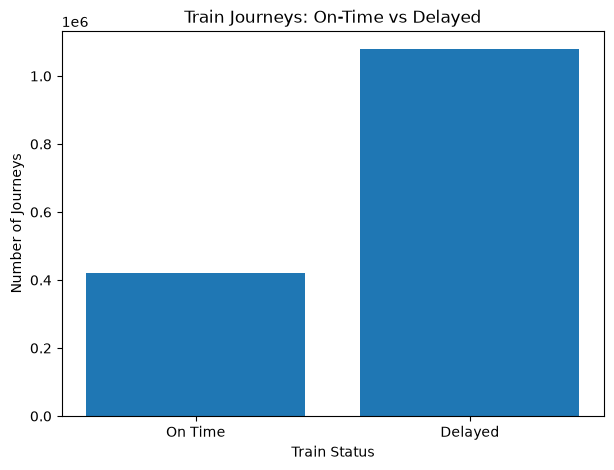

In [13]:
delay_counts = train["is_delayed"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["On Time", "Delayed"],
    delay_counts.values
)

plt.title("Train Journeys: On-Time vs Delayed")
plt.xlabel("Train Status")
plt.ylabel("Number of Journeys")

plt.show()

Delay minutes analysis

How many minutes was the delay?

In [15]:
train["delay_minutes"].describe().round(2)

count    1500000.00
mean          97.73
std           66.17
min            0.00
25%           13.00
50%          111.00
75%          140.00
max          579.00
Name: delay_minutes, dtype: float64

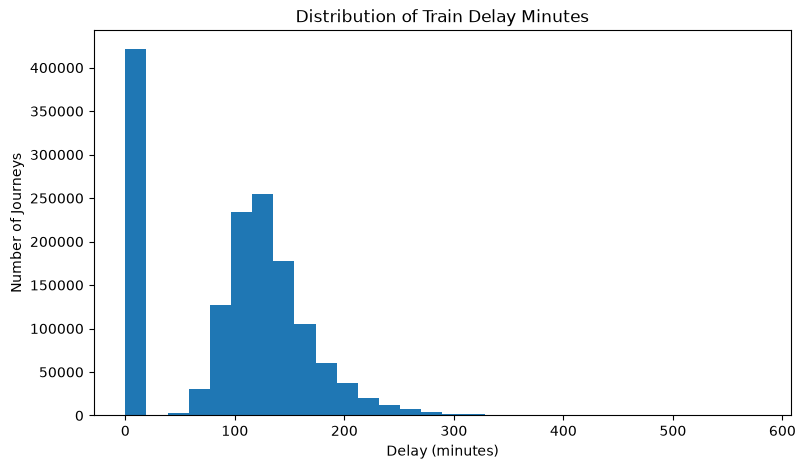

In [17]:
plt.figure(figsize=(9, 5))

plt.hist(
    train["delay_minutes"],
    bins=30
)

plt.title("Distribution of Train Delay Minutes")
plt.xlabel("Delay (minutes)")
plt.ylabel("Number of Journeys")

plt.show()

Delay distribution

In [19]:
delayed_trains = train[train["is_delayed"] == 1]

delayed_trains["delay_minutes"].describe().round(2)

count    1078329.00
mean         133.21
std           40.08
min           37.00
25%          106.00
50%          127.00
75%          152.00
max          579.00
Name: delay_minutes, dtype: float64